# TRAINING AND ASSESSING THE MODELS

For this notebook please make sure that in *./csv/datasets* there are the following files:
- csv/datasets/nifh_dataset.csv
- csv/datasets/nifh_dataset_simple_tr.csv
- csv/datasets/nifh_dataset_simple_tr_out.csv
- csv/datasets/nifh_dataset_scikit_0.csv
- csv/datasets/nifh_dataset_scikit_2.csv

## Libraries

In [10]:
import sys
print(sys.executable)

/usr/bin/python


In [11]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib
import seaborn as sns
import joblib as joblib

## Column names are stored 

In [12]:
x_columns = ['O2_knn', 'T_knn', 'N_knn', 'P_knn', 'Fe_knn', 'solar_knn']
y_columns =['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

## Functions

In [13]:
def plotColsOnMap(cols,df, log_range = False, mult = 1):
    #the index is reset from using lat and lon just in case
    df_reset = df.reset_index()

    #the number of rows varies depending on the number of columns to plot
    rows = (len(cols)//2) + (len(cols)%2==1)

    #a set of subplots is created
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, rows*4), subplot_kw={"projection": ccrs.PlateCarree()})

    #we plot each column
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]#subplot

        #we want to see the coastlines on the globe and only take not null values
        ax.add_feature(cfeature.COASTLINE)
        valid_data = df_reset[df_reset[col].notna()]
## Column names are stored 
        #this sets the logorithmic scale to be exactly like in the paper instead of default
        norm = matplotlib.colors.LogNorm(vmin=1e3, vmax=1e11)
        if(not log_range):
            norm = None

        #scatter plot is created
        sc = ax.scatter(
            valid_data["LONGITUDE"],
            valid_data["LATITUDE"],
            c=valid_data[col]*mult,
            cmap="viridis",
            s=40,
            transform=ccrs.PlateCarree(),
            norm=norm
        )

        #we want to see the entire globe and not just the values 
        ax.set_xlim(-180,180)
        ax.set_ylim(-90,90)

        label = "nifH Gene (copies m-3" if "nifH Gene (copies m-3)" in col else ""

        plt.colorbar(sc, ax=ax, label=label)
        ax.set_title(col.replace("x106 ",""))

    plt.tight_layout()
    plt.show()

In [14]:
def histCols(cols,df, log_range = False, transf = (lambda x: x), suptitle=""):
    #the index is reset from using lat and lon just in case
    df_reset = df.reset_index()

    #the number of rows varies depending on the number of columns to plot
    rows = (len(cols)//2) + (len(cols)%2==1)

    #a set of subplots is created
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, rows*4))

    #we plot each column
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]#subplot

        valid_data = df_reset[df_reset[col].notna()]
        transf(valid_data[col]).hist(bins=50, ax=ax)

        ax.set_title(col)

    
    if(len(suptitle)>0):
        plt.suptitle(suptitle, fontsize=16)

    plt.tight_layout()
    plt.show()

In [15]:
def getData(feature, dataset):
    return dataset.dropna(subset=feature, how='all')[x_columns+feature]

In order to make testing different models easier I created a function for that purpose. 

In [16]:
from sklearn.metrics import root_mean_squared_error

def train_model(model, X_train, y_train, model_name="-"):
    #we train the model
    model.fit(X_train, y_train)

    #get the preictions
    predictions = model.predict(X_train)

    error_rate = root_mean_squared_error(y_train, predictions)
    print("Model {0} achieved RMSE score of {1} on train dataset".format(model_name, error_rate))

In [17]:
class DummyModel():
    value=None

    def __init__(self):
        self.value=None

    def fit(self, X_train, y_train):
        self.value = np.mean(y_train)

    def predict(self, X_train):
        return np.full(len(X_train), self.value)


## Loading transofrmers
In join_csv we created several transformers 

In [18]:
class SimpleTransformer():
    transforms = {
        "O2_knn":(lambda x: np.log(x*(10**6)+10)),
        "T_knn":(lambda x: np.log(x*(10**6)+10)),
        "N_knn":(lambda x: np.log(x*(10**3)+10)),
        "P_knn":(lambda x: np.log(x*(10**6)+10)),
        "Fe_knn":(lambda x: np.log(x*1000+10)),
        "solar_knn":(lambda x:x),
        'Trichodesmium nifH Gene (x106 copies m-3)':(lambda x: np.log(x*(10**6)+10)),
        'UCYN-A nifH Gene (x106 copies m-3)':(lambda x: np.log(x*(10**6)+10)),
        'UCYN-B nifH Gene (x106 copies m-3)':(lambda x: np.log(x*(10**6)+10))
    }

    reverse_transforms = {
        "O2_knn":(lambda x: (np.exp(x)-10)/(10**6)),
        "T_knn":(lambda x: (np.exp(x)-10)/(10**6)),
        "N_knn":(lambda x: (np.exp(x)-10)/(10**3)),
        "P_knn":(lambda x: (np.exp(x)-10)/(10**6)),
        "Fe_knn":(lambda x: (np.exp(x)-10)/(10**3)),
        "solar_knn":(lambda x:x),
        'Trichodesmium nifH Gene (x106 copies m-3)':(lambda x: (np.exp(x)-10)/(10**6)),
        'UCYN-A nifH Gene (x106 copies m-3)':(lambda x: (np.exp(x)-10)/(10**6)),
        'UCYN-B nifH Gene (x106 copies m-3)':(lambda x: (np.exp(x)-10)/(10**6))
    }

    def __init__(self):
        print("simple transformer created")

    ''' 
    apply transformations to a set of columns based on a dictionary of the format:
    col_name --> lambda function on a numpy array
    '''
    def __applyTransormations(self, dct,df):
        new_df = pd.DataFrame()
        for key in dct.keys():
            new_df[key] = dct[key](df[key])
        return new_df
    
    ''' 
    forward transofrm before training
    '''
    def transform(self,df):
        print("applying the transform")
        return self.__applyTransormations(self.transforms, df)

    ''' 
    backward transform for the model results
    '''
    def reverse_transform(self,df):
        print("apply reverse")
        return self.__applyTransormations(self.reverse_transforms, df)


In [19]:
transformers = joblib.load("./model/transformers")

## Loading the datasets

We need to load the data into the notebook and store it in a dictionary

In [20]:
#this is how paths are stored and the names persist in the code
paths = {
    "raw_data": "./csv/datasets/nifh_dataset.csv",
    "simple_transform": "./csv/datasets/nifh_dataset_simple_tr.csv",
    "simple_transform without 'outliers'":"./csv/datasets/nifh_dataset_simple_tr_out.csv",
    "scikit scaler 0": "./csv/datasets/nifh_dataset_scikit_0.csv",
    "scikit scaler 2": "./csv/datasets/nifh_dataset_scikit_2.csv"
}

#here we store the pandas dataframes before splitting
datasets = dict()

#we open and store the csv files
for name, path in paths.items():
    datasets[name] = pd.read_csv(path)[x_columns+y_columns]

## Displaying data
I want to show the initial distributions as it can be useful when interpreting results.

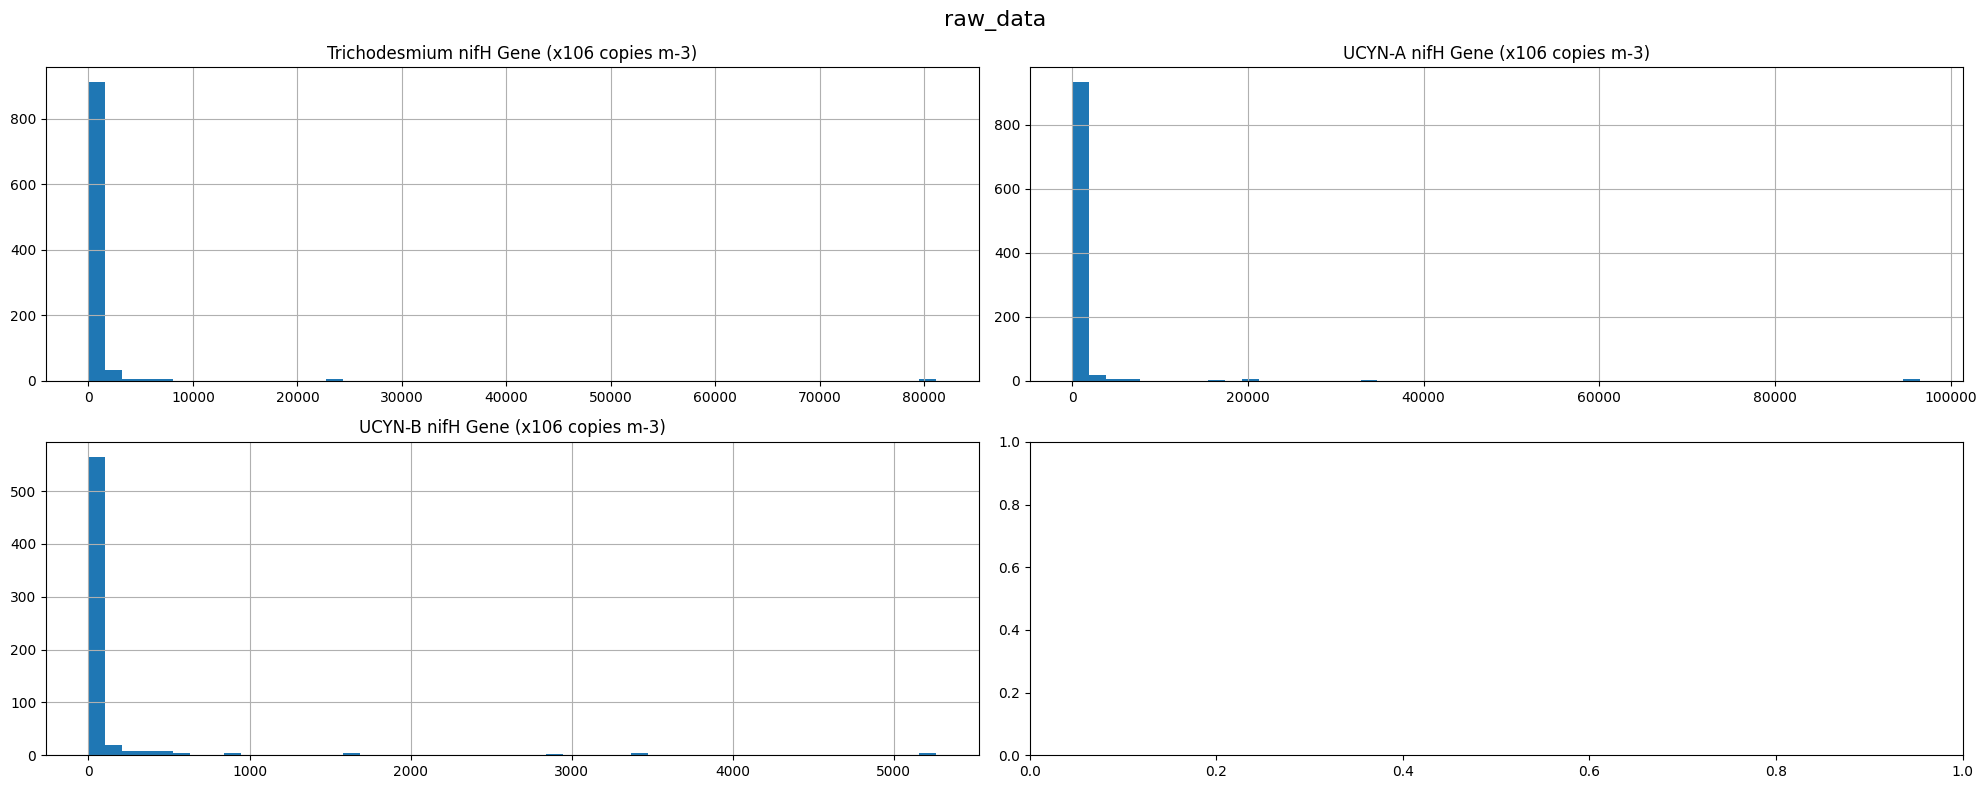

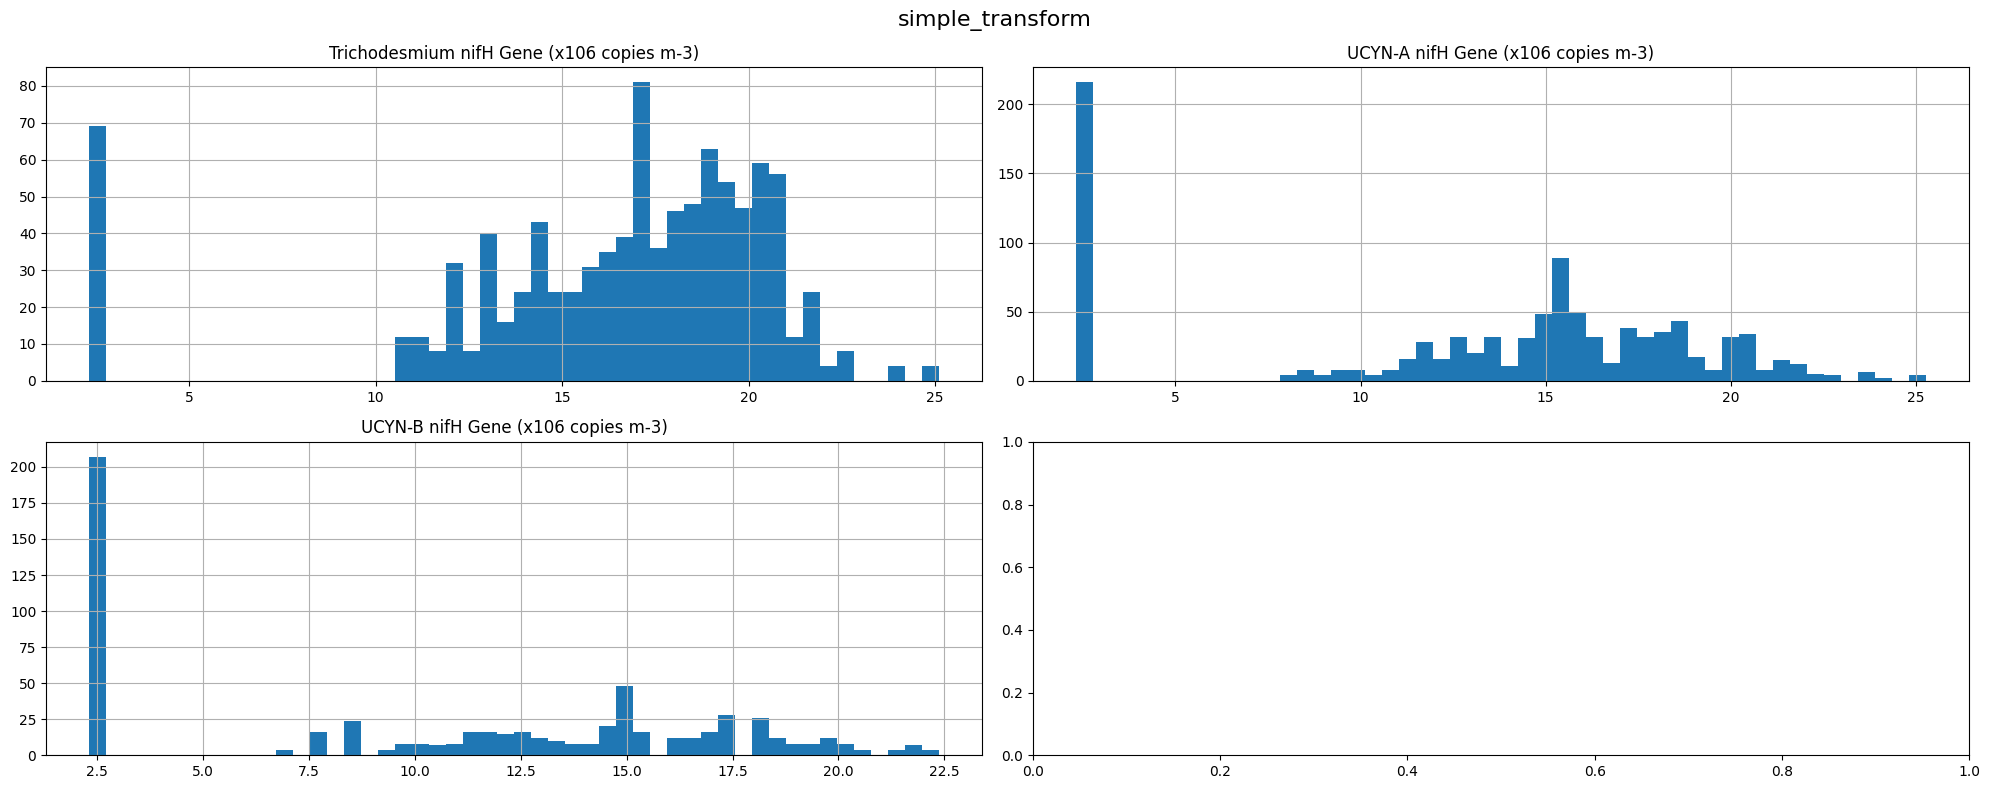

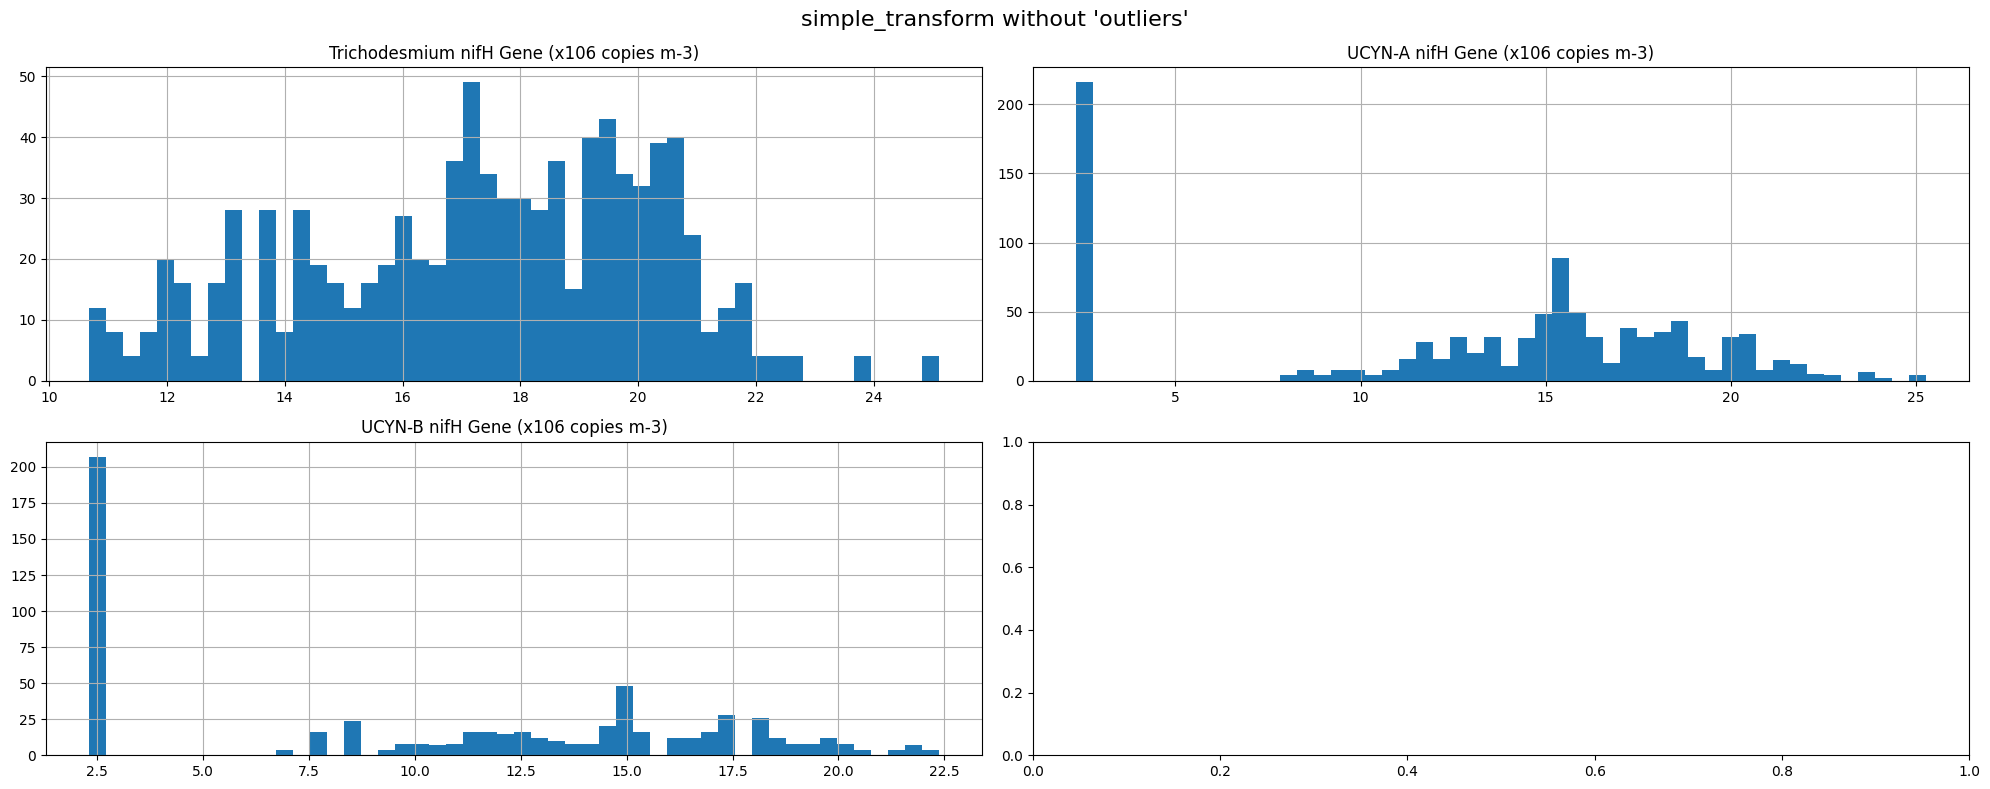

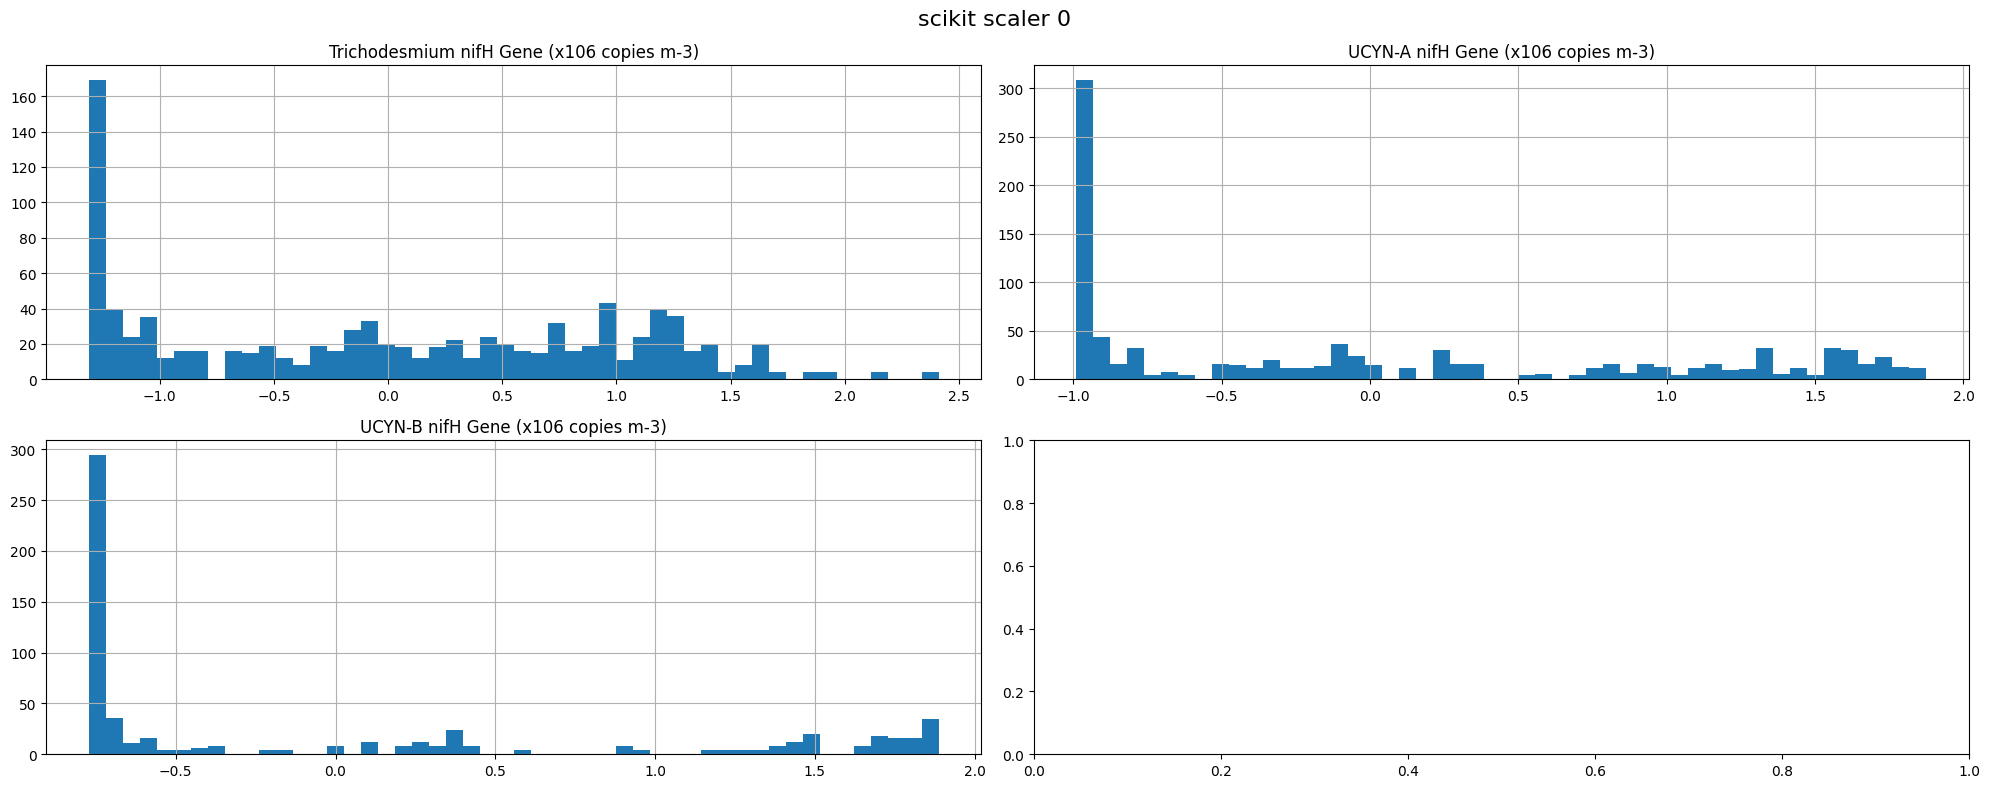

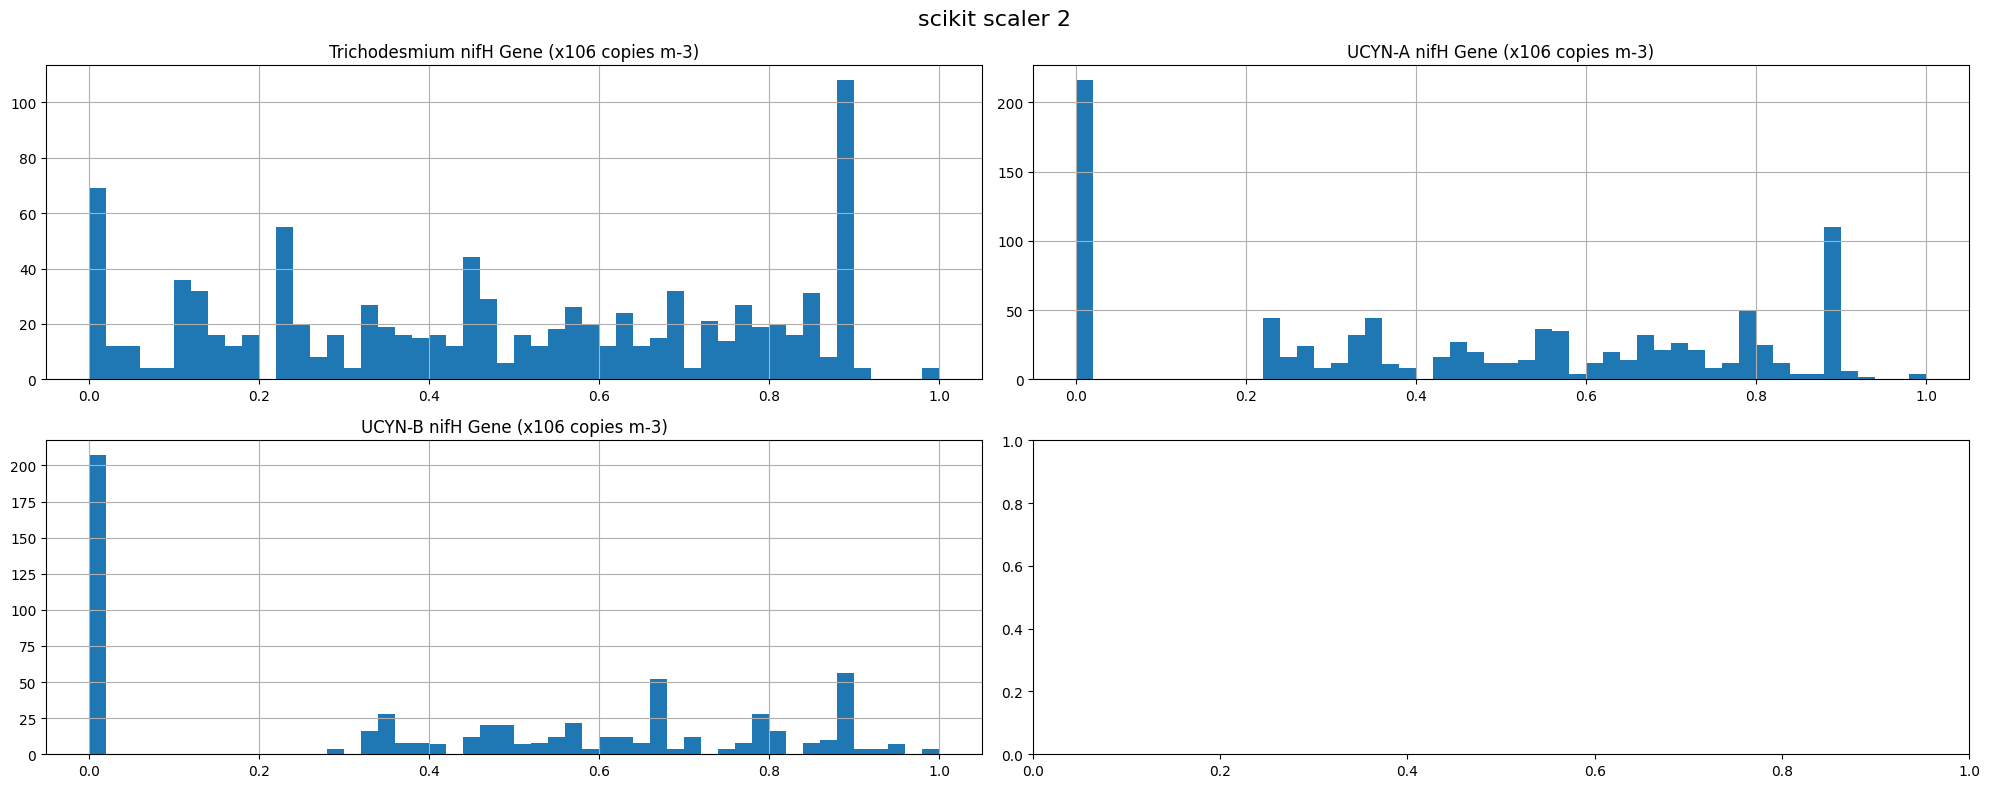

In [21]:
for name, dataset in datasets.items():
    histCols(y_columns, dataset, suptitle=name)

## Train test split

In order to verify that the data is actually generalizable and that the model can preditct on data it has never seen before we need to test it on such data that we set aside before training.

The data structure is the following:

```
training data:
{                                                         
    "name": {                                        
        "feature":{X_train, X_test, y_train, y_test}    
        "feature1":{X_train, X_test, y_train, y_test}   
        "feature2":{X_train, X_test, y_train, y_test}   
    }                                                   
    "name2": {                                          
        ...                                             
    }                                                      
}                                                       
```

In [22]:
from sklearn.model_selection import train_test_split

training_data = dict()

for name, dataset in datasets.items():
    training_data[name]=dict()
    for feature in y_columns:
        #we filter the data by the feature before splitting
        temp_ds = getData([feature], dataset)
        X_train, X_test, y_train, y_test = train_test_split(temp_ds[x_columns], temp_ds[[feature]], test_size=0.2, random_state=42)

        #we store the split data
        temp_dict = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test
        }

        #add results to the dictionary
        training_data[name][feature] = temp_dict

## Training a baseline model

For a good baseline we can consider using linear regression and just taking the mean. Likely neither will be great, but that is the point. We want to see that better more suited models can achieve higher results.

In [23]:
for name in paths.keys():
    print("Dataset: {0}".format(name))
    for feature in y_columns:
        data = training_data[name][feature]
        X_train = data["X_train"]
        y_train = data["y_train"]

        model = DummyModel()
        model_name ="dummy model"

        train_model(model, X_train=X_train, y_train=y_train, model_name=model_name)
    print("")


Dataset: raw_data
Model dummy model achieved RMSE score of 6078.037656839828 on train dataset
Model dummy model achieved RMSE score of 6310.283268263187 on train dataset
Model dummy model achieved RMSE score of 597.5153498432949 on train dataset

Dataset: simple_transform
Model dummy model achieved RMSE score of 4.8349482524401255 on train dataset
Model dummy model achieved RMSE score of 6.504462978737 on train dataset
Model dummy model achieved RMSE score of 6.5954116517548655 on train dataset

Dataset: simple_transform without 'outliers'
Model dummy model achieved RMSE score of 2.9137232106557276 on train dataset
Model dummy model achieved RMSE score of 6.504462978737 on train dataset
Model dummy model achieved RMSE score of 6.5954116517548655 on train dataset

Dataset: scikit scaler 0
Model dummy model achieved RMSE score of 1.0059982592821621 on train dataset
Model dummy model achieved RMSE score of 1.0075851713875708 on train dataset
Model dummy model achieved RMSE score of 1.0073